In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [41]:
data_linear = pd.read_csv("data/linear/test_set.csv", index_col=0, usecols=['Date', 'signal', 'close'], parse_dates=True)
data_linear['predicted_signal'] = pd.read_csv("data/linear/pred.csv", header=None).set_index(data_linear.index)

data_linear.head(5)

,close,signal,predicted_signal
Date,,,
2025-06-04,1.509060,1,1.0
2025-06-05,1.548004,1,0.0
2025-06-06,1.581400,0,0.0
2025-06-09,1.581400,1,0.0
2025-06-10,1.620689,0,0.0


In [42]:
# pct_change and strategy_returns
data_linear['pct_change'] = data_linear['close'].pct_change()

data_linear['strategy_returns'] = data_linear['predicted_signal'].shift(1) * data_linear['pct_change']
data_linear.dropna(inplace=True)

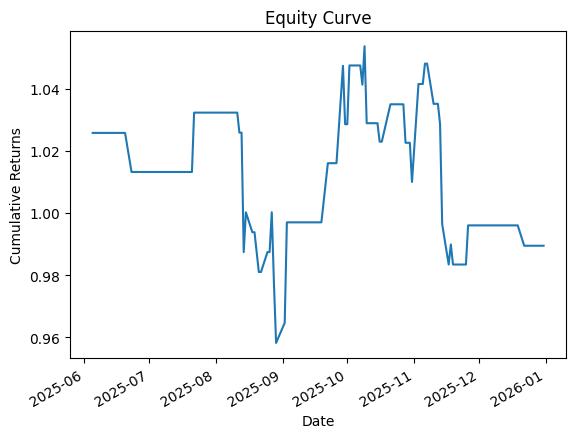

In [43]:
# Equity Curve

data_linear['cumulative_returns'] = (data_linear['strategy_returns']+1).cumprod()

data_linear['cumulative_returns'].plot()

plt.title('Equity Curve')
plt.ylabel('Cumulative Returns')

plt.show()

In [44]:
# Function to get trade details:
# current_position, entry_time, entry_price, exit_time, exit_price

def get_trades(data, price, signal):
    trades = pd.DataFrame()

    current_position = 0
    entry_time = ''

    for i in data.index:
        new_position = data.loc[i, signal]

        if new_position != current_position:

            if entry_time != '':
                entry_price = data.loc[entry_time, price]
                
                exit_time = i
                exit_price = data.loc[exit_time, price]

                trade_details = pd.DataFrame([[current_position, entry_time, entry_price, exit_time, exit_price]])
                trades = pd.concat([trades, trade_details])

                entry_time = ''
            
            if new_position != 0:
                entry_time = i

            current_position = new_position

    trades.columns = ['Position', 'Entry Time', 'Entry Price', 'Exit Time', 'Exit Price']
    trades['PnL'] = (trades['Exit Price'] - trades['Entry Price']) * trades['Position']

    return trades

In [45]:
trade_log_l = get_trades(data_linear, 'close', 'predicted_signal')

trade_log_l

,Position,Entry Time,Entry Price,Exit Time,Exit Price,PnL
0,1.0,2025-06-20,1.601045,2025-06-23,1.581400,-0.019645
0,1.0,2025-07-21,1.561755,2025-07-22,1.591222,0.029467
0,1.0,2025-08-11,1.571578,2025-08-12,1.561755,-0.009822
0,1.0,2025-08-13,1.571578,2025-09-03,1.527329,-0.044248
0,1.0,2025-09-19,1.557082,2025-09-22,1.586836,0.029753
0,1.0,2025-09-26,1.606671,2025-09-30,1.626506,0.019835
0,1.0,2025-10-01,1.616589,2025-10-02,1.646342,0.029753
0,1.0,2025-10-06,1.676095,2025-10-10,1.646342,-0.029753
0,1.0,2025-10-15,1.715766,2025-10-16,1.705848,-0.009918
0,1.0,2025-10-17,1.686013,2025-10-22,1.705848,0.019835


In [46]:
def get_analytics(trades):
    """
    Take a trade log and return a DataFrame object of trade analytics

    Args:
        trades (DataFrame):  DataFrame object with 'Position', 'Entry Time',
                                    'Entry Price', 'Exit Time', 'Exit Price' data
                                    for each trade
    
    Returns:
        analytics (DataFrame):  DataFrame object with columns: Number of long trades,
                                Number of short trades, Total number of trades, Gross
                                profit, Gross loss, Net profit/loss, Number of winning
                                trades, Number of losing trades, Win percentage, Loss
                                percentage, Average profit per winning trade, Average loss
                                per losing trade
    """
    analytics = pd.DataFrame(index=['Strategy'])

    analytics['num_of_long'] = len(trades.loc[trades.Position == 1])
    analytics['num_of_short'] = len(trades.loc[trades.Position == -1])
    analytics['total_trades'] = analytics.num_of_long + analytics.num_of_short
    
    analytics['gross_profit'] = trades.loc[trades.PnL > 0].PnL.sum()
    analytics['gross_loss'] = trades.loc[trades.PnL < 0].PnL.sum()
    analytics['net_profit'] = trades.PnL.sum()

    analytics['winners'] = len(trades.loc[trades.PnL > 0])
    analytics['losers'] = len(trades.loc[trades.PnL <= 0])
    analytics['win_percentage'] = 100 * (analytics['winners'] / analytics['total_trades'])
    analytics['loss_percentage'] = 100 * (analytics.losers / analytics.total_trades) # trying out different syntax
    analytics['per_trade_PnL_winners'] = trades.loc[trades.PnL > 0].PnL.mean()
    analytics['per_trade_PnL_losers'] = trades.loc[trades.PnL <= 0].PnL.mean()

    analytics = round(analytics, 2)

    return analytics.T

In [47]:
analytics_l = get_analytics(trade_log_l)

analytics_l

,Strategy
num_of_long,19.00
num_of_short,0.00
total_trades,19.00
gross_profit,0.19
gross_loss,-0.24
net_profit,-0.05
winners,8.00
losers,11.00
win_percentage,42.11
loss_percentage,57.89


cumulative_returns: -1.05%
annualized_return: -1.85%
annualized_volatility: 14.00%
maximum drawdown: -7.19%
Sharpe ratio: -0.06


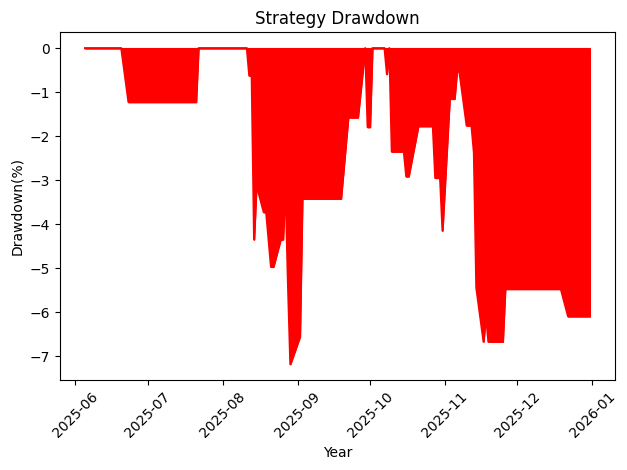

In [48]:
cumulative_returns = (data_linear['cumulative_returns'].iloc[-1] - 1) * 100

print(f"cumulative_returns: {cumulative_returns:.2f}%")

annualized_return = (data_linear['cumulative_returns'].iloc[-1] ** (252/len(data_linear)) - 1) * 100

print(f"annualized_return: {annualized_return:0.2f}%")

annualized_volatility = data_linear['strategy_returns'].std() * np.sqrt(252) * 100

print(f"annualized_volatility: {annualized_volatility:0.2f}%")

running_max = np.maximum.accumulate(data_linear['cumulative_returns'].dropna())

running_max[running_max < 1] = 1

drawdown = (data_linear['cumulative_returns']/running_max - 1) * 100

max_dd = drawdown.min()
print(f"maximum drawdown: {max_dd:0.2f}%")

# Sharp Ratio

r_f = 0 # risk free rate (assume that it is 0 for simplicity)
sharpe_ratio = (data_linear['strategy_returns'].mean() - r_f) / data_linear['strategy_returns'].std() \
                * np.sqrt(252)

print(f"Sharpe ratio: {sharpe_ratio:0.2f}")

# transaction costs and slippage were omitted

fig = plt.figure()
plt.plot(drawdown, color='r')
plt.fill_between(drawdown.index, drawdown.values, color='r')
plt.title("Strategy Drawdown")
plt.ylabel("Drawdown(%)")
plt.xlabel("Year")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [4]:
import numpy as np

array = np.array(['h', 'e', 'y'])
type(array[0])

numpy.str_